In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

import specula
specula.init(0)

from lbt_synim import LBTSynIM

2026-10-05 18:20:50,819 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-10-05 18:20:51,250 [INFO]: [specula]: Default device is GPU number 0


In [2]:
import matplotlib as mpl
from cycler import cycler

cmap = mpl.colormaps['hot'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.0, 1.0, 7)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle
plt.rcParams['image.cmap'] = 'hot' # 4. Change the default colormap for images/scatter plots
plt.rcParams.update({
    "text.usetex": True, # Use LaTeX to write all text
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"] # Specifically use the classic LaTeX font
})
plt.rcParams['image.origin'] = 'lower'

In [3]:
lbtidx_im = np.linalg.pinv(fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/data/Rec_20251120_085351.fits')) # LBTIdx
lbtisx_im = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv32sx/im/pyr3.0_40x40_lbt_refim.fits') # LBTI sx
lucidx_im = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_lbt_refim.fits') # LUCI dx

In [4]:
# m2c_dx = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/m2c/asm_v30dx_m2c.fits')
# m2c_sx = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv32sx/m2c/asm_v32sx_m2c.fits')
# kl_dx = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_kl_inv.fits')
# kl_sx = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv32sx/ifunc/asm_v32sx_kl_inv.fits')
# mask_dx = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupilstop/asm_v30dx_197pixels.fits')
# mask_sx = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv32sx/pupilstop/asm_v32sx_198pixels.fits')
# print(m2c_dx.shape,kl_dx.shape,mask_dx.shape)

In [5]:
# from scipy.io import readsav

# sav_dx = readsav('/raid1/mmenessini/LBTData/KLv30dx/phase_matrix.sav')
# sav_sx = readsav('/raid1/mmenessini/LBTData/KLv32sx/phase_matrix.sav')

# def analyse_sav(savfile):
#     print(savfile.keys())
#     mask = np.zeros([savfile['dpix'],savfile['dpix']]).flatten()
#     mask[savfile['idx_mask']] = 1
#     mask = mask.reshape([savfile['dpix'],savfile['dpix']])
#     # plt.figure()
#     # plt.imshow(mask)
#     print(savfile['dpix'])
#     m2c = savfile['klm2c']
#     act_ids = np.sum(abs(m2c),axis=0)>0
#     mode_ids = np.sum(abs(m2c),axis=1)>0
#     m2c = m2c[:,act_ids]
#     m2c = m2c[mode_ids,:]
#     kl = savfile['klmatrix']
#     klinv = np.linalg.pinv(kl)
#     print(m2c.shape)
#     print(klinv.shape)
#     print(savfile['idx_mask'].shape)
#     return m2c, mask, klinv


# m2c_dx_sav, mask_dx_sav, kl_dx_sav = analyse_sav(sav_dx)
# m2c_sx_sav, mask_sx_sav, kl_sx_sav  = analyse_sav(sav_sx)

# plt.figure()
# # plt.imshow(np.logical_xor(mask_dx,mask_dx_sav))
# plt.plot(np.sum(kl_dx_sav-kl_dx,axis=0))

In [ ]:
lucidx = LBTSynIM('LUCIdx')
lbtisx = LBTSynIM('LBTIsx')
# misreg = lucidx.update_registration(lucidx_im)
misreg = lbtisx.update_registration(lbtisx_im)

2026-10-05 18:20:51,933 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-10-05 18:20:51,935 [INFO]: [specula]: Default device is GPU number 0


In [7]:
# imat_dl   = lucidx.compute_interaction_matrix(rMod=2)
# rec    = lucidx.compute_reconstructor(imat_dl, Nmodes=550)

In [8]:
# print(imat_dl.shape,rec.shape)

In [ ]:
imat_pc1   = lucidx.compute_interaction_matrix(rMod=2, seeing=1.0)

Saved /raid1/mmenessini/LBTsynIM/data/corr_vec_20261005_182052


2026-10-05 18:20:52,724 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-10-05 18:20:52,906 [INFO]: [specula]: Default device is GPU number 0
2026-10-05 18:20:52,999 [INFO]: [specula.simul]: Reading parameters from ./config/syn_soul_im.yml
2026-10-05 18:20:53,006 [INFO]: [specula.simul]: Reading additional parameters from ./config/pc_blocks.yml
2026-10-05 18:20:53,011 [INFO]: [specula.simul]: Reading additional parameters from /raid1/mmenessini/LBTsynIM/data/_overrides_pc_20261005_182052_0.yml
2026-10-05 18:20:53,014 [INFO]: [specula.simul]: overrides: 
2026-10-05 18:20:53,015 [INFO]: [specula.simul]: self.trigger_order=['main', 'pushpull', 'source_ngs', 'pupilstop', 'seeing_random', 'dm', 'atmo_random', 'prop', 'modal_analysis_random', 'pyr', 'scale_random', 'ocam', 'dm_random', 'pyr_slopes', 'atmo_pc', 'pyr_im_calibrator', 'ef_mode']
2026-10-05 18:20:53,015 [INFO]: [specula.simul]: self.trigger_order_idx=[0, 0, 0, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6]

197 396


2026-10-05 18:20:54,023 [INFO]: [specula.IFunc]: cupy memory used by IFunc: 73.9189453125 MB
2026-10-05 18:20:54,023 [INFO]: [specula.simul]: Restoring: /raid1/mmenessini/LBTsynIM/m2c/asm_v30dx_m2c.fits
2026-10-05 18:20:54,032 [INFO]: [specula.M2C]: cupy memory used by M2C: 1.609375 MB
2026-10-05 18:20:54,047 [INFO]: [initialising]: AtmoRandomPhase: zenith angle is defined as: 0.0 deg
2026-10-05 18:20:54,047 [INFO]: [initialising]: AtmoRandomPhase: airmass is: 1.0
2026-10-05 18:20:54,048 [INFO]: [source_ngs]: source.phot_density: magnitude is 7.0, and flux (output of n_phot with width=1e-9, surf=1) is 105244.94486611686
2026-10-05 18:20:54,430 [INFO]: [specula.simul]: Restoring: /raid1/mmenessini/LBTsynIM/ifunc/IFuncInv_LUCIdx_20261005_171307.fits
2026-10-05 18:20:54,552 [INFO]: [specula.IFuncInv]: cupy memory used by IFuncInv: 146.865234375 MB
2026-10-05 18:20:54,554 [INFO]: [specula.calib_manager]: Reading: /raid1/mmenessini/LBTsynIM/data/corr_vec_20261005_182052.fits
2026-10-05 18:2

197 396


...

2026-10-05 18:32:31,964 [INFO]: [specula.IFunc]: cupy memory used by IFunc: 73.9189453125 MB
2026-10-05 18:32:31,964 [INFO]: [specula.simul]: Restoring: /raid1/mmenessini/LBTsynIM/m2c/asm_v30dx_m2c.fits
2026-10-05 18:32:31,974 [INFO]: [specula.M2C]: cupy memory used by M2C: 1.609375 MB
2026-10-05 18:32:31,986 [INFO]: [initialising]: AtmoRandomPhase: zenith angle is defined as: 0.0 deg
2026-10-05 18:32:31,986 [INFO]: [initialising]: AtmoRandomPhase: airmass is: 1.0
2026-10-05 18:32:31,987 [INFO]: [source_ngs]: source.phot_density: magnitude is 7.0, and flux (output of n_phot with width=1e-9, surf=1) is 105244.94486611686
2026-10-05 18:32:31,992 [INFO]: [specula.lib.phasescreen_manager]: Calculating phasescreen...
2026-10-05 18:32:35,351 [INFO]: [specula.lib.phasescreen_manager]: Done
2026-10-05 18:32:35,355 [INFO]: [specula.simul]: Restoring: /raid1/mmenessini/LBTsynIM/ifunc/IFuncInv_LUCIdx_20261005_171307.fits
2026-10-05 18:32:35,490 [INFO]: [specula.IFuncInv]: cupy memory used by IFun

197 396


2026-10-05 18:32:55,380 [INFO]: [specula.IFunc]: cupy memory used by IFunc: 73.9189453125 MB
2026-10-05 18:32:55,380 [INFO]: [specula.simul]: Restoring: /raid1/mmenessini/LBTsynIM/m2c/asm_v30dx_m2c.fits
2026-10-05 18:32:55,390 [INFO]: [specula.M2C]: cupy memory used by M2C: 1.609375 MB
2026-10-05 18:32:55,401 [INFO]: [initialising]: AtmoRandomPhase: zenith angle is defined as: 0.0 deg
2026-10-05 18:32:55,401 [INFO]: [initialising]: AtmoRandomPhase: airmass is: 1.0
2026-10-05 18:32:55,402 [INFO]: [source_ngs]: source.phot_density: magnitude is 7.0, and flux (output of n_phot with width=1e-9, surf=1) is 105244.94486611686
2026-10-05 18:32:55,408 [INFO]: [specula.lib.phasescreen_manager]: Calculating phasescreen...
2026-10-05 18:32:58,779 [INFO]: [specula.lib.phasescreen_manager]: Done
2026-10-05 18:32:58,783 [INFO]: [specula.simul]: Restoring: /raid1/mmenessini/LBTsynIM/ifunc/IFuncInv_LUCIdx_20261005_171307.fits
2026-10-05 18:32:58,916 [INFO]: [specula.IFuncInv]: cupy memory used by IFun

197 396


2026-10-05 18:33:18,606 [INFO]: [specula.IFunc]: cupy memory used by IFunc: 73.9189453125 MB
2026-10-05 18:33:18,606 [INFO]: [specula.simul]: Restoring: /raid1/mmenessini/LBTsynIM/m2c/asm_v30dx_m2c.fits
2026-10-05 18:33:18,615 [INFO]: [specula.M2C]: cupy memory used by M2C: 1.609375 MB
2026-10-05 18:33:18,627 [INFO]: [initialising]: AtmoRandomPhase: zenith angle is defined as: 0.0 deg
2026-10-05 18:33:18,627 [INFO]: [initialising]: AtmoRandomPhase: airmass is: 1.0
2026-10-05 18:33:18,628 [INFO]: [source_ngs]: source.phot_density: magnitude is 7.0, and flux (output of n_phot with width=1e-9, surf=1) is 105244.94486611686
2026-10-05 18:33:18,631 [INFO]: [specula.lib.phasescreen_manager]: Calculating phasescreen...


In [ ]:
def show2d_slopes(slopes,npix=120,normalize:bool=False,title='',vmin=None,vmax=None,show=True,ppath='pyr_pupdata_40x40',newfig:bool=False):
    if normalize:
        slopes -= np.mean(slopes)
        slopes_rms = np.std(slopes)
        slopes /= slopes_rms

    filepath=f'/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/{ppath}.fits'
    pup_hdu = fits.open(filepath)
    pup_ids = pup_hdu[1].data
    fimg = np.zeros(npix**2)
    np.put(fimg, pup_ids[:,0], slopes[:len(slopes)//2])
    np.put(fimg, pup_ids[:,1], slopes[len(slopes)//2:])
    f2d = fimg.reshape([npix,npix])

    if vmin is None:
        vmin = np.min(f2d)
    if vmax is None:
        vmax = np.max(f2d)
    
    if show:
        if newfig:
            plt.figure()
        plt.imshow(np.ma.masked_array(f2d,mask=np.abs(f2d)==0),origin='lower',cmap='RdBu',vmin=vmin,vmax=vmax)
        plt.ylim([12,60])
        plt.xlim([12,108])
        plt.axis('off')
        plt.title(title)
        plt.colorbar(shrink=0.5)
    return f2d

In [ ]:
pupids = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/pup_ids.fits')
pyr_masks = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/lbt_pupmask_shift.fits').astype(bool)

rec = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/data/Rec_20251120_085351.fits')
refim = np.linalg.pinv(rec)

def show_im_slopes_idx(idx:int,im=refim):
    half_mask = pyr_masks[:60,:120].astype(bool)
    img = np.zeros(np.size(half_mask))
    img[half_mask.flatten()] = im[pupids,idx]
    img = img.reshape([60,120])
    plt.imshow(np.ma.masked_array(img,mask=img==0),origin='lower',cmap='RdBu')
    plt.colorbar(shrink=0.5)
    plt.ylim([12,60])
    plt.xlim([12,120-12-1])
    plt.axis('off')

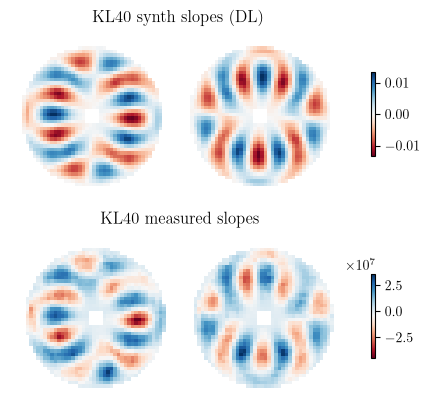

In [ ]:
idx = 40
plt.figure()
plt.subplot(2,1,2)
show_im_slopes_idx(idx=idx)
plt.title(f'KL{idx} measured slopes')

aux = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_lbti_synim.fits')
synim = aux.copy()
synim[:2512//2,:] = aux[2512//2:,:]
synim[2512//2:,:] = aux[:2512//2,:]*-1
plt.subplot(2,1,1)
f2dopt=show2d_slopes(synim[:,idx],ppath='lbt_pupdata',title=f'KL{idx} synth slopes (DL)')